# Key Findings: Media Framing Analysis (2015-2021)

This notebook summarizes the claims from our analysis of 80,783 news articles across 9 outlets.

**Supporting notebooks:**
- `Frame_Cooccurrence_Analysis.ipynb` - Frame pair co-occurrence patterns
- `Framing_Drift_Analysis.ipynb` - Temporal trends in framing
- `Outlet_Framing_Analysis.ipynb` - Outlet and political valence comparisons
- `Event_Framing_Analysis.ipynb` - Frame shifts around major events

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_parquet('data/merged_topic_and_frames_filtered.parquet')
df['date'] = pd.to_datetime(df['date'])
df['quarter'] = df['date'].dt.to_period('Q')

frames = ['economic', 'fairness', 'public_op', 'political', 'quality_life', 
          'crime', 'culture', 'health', 'legality', 'morality', 
          'policy', 'regulation', 'security', 'cap&res']

frame_matrix = np.array(df['vector'].tolist())
for i, frame in enumerate(frames):
    df[f'frame_{frame}'] = frame_matrix[:, i]
frame_cols = [f'frame_{f}' for f in frames]

valence_map = {'Left': 'Left', 'Lean Left': 'Left', 'Center': 'Center', 'Lean Right': 'Right', 'Right': 'Right'}
df['valence'] = df['bias'].map(valence_map)

print(f'Dataset: {len(df):,} articles | {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Outlets: {df["outlet_name"].nunique()} | Topics: {df["topic_top1"].nunique()} | Frames: {len(frames)}')

Dataset: 80,783 articles | 2015-01-01 to 2021-12-31
Outlets: 9 | Topics: 11 | Frames: 14


---
# SUPPORTED CLAIMS
---

## 1. Outlets Have Distinct Framing Fingerprints

**Claim:** Different news outlets use frames at dramatically different rates.

**Evidence:** Frame usage varies widely across outlets (see computed ranges below). Chi-square tests confirm outlet-frame associations are statistically significant.

*See: `Outlet_Framing_Analysis.ipynb` for full breakdown and statistical tests*

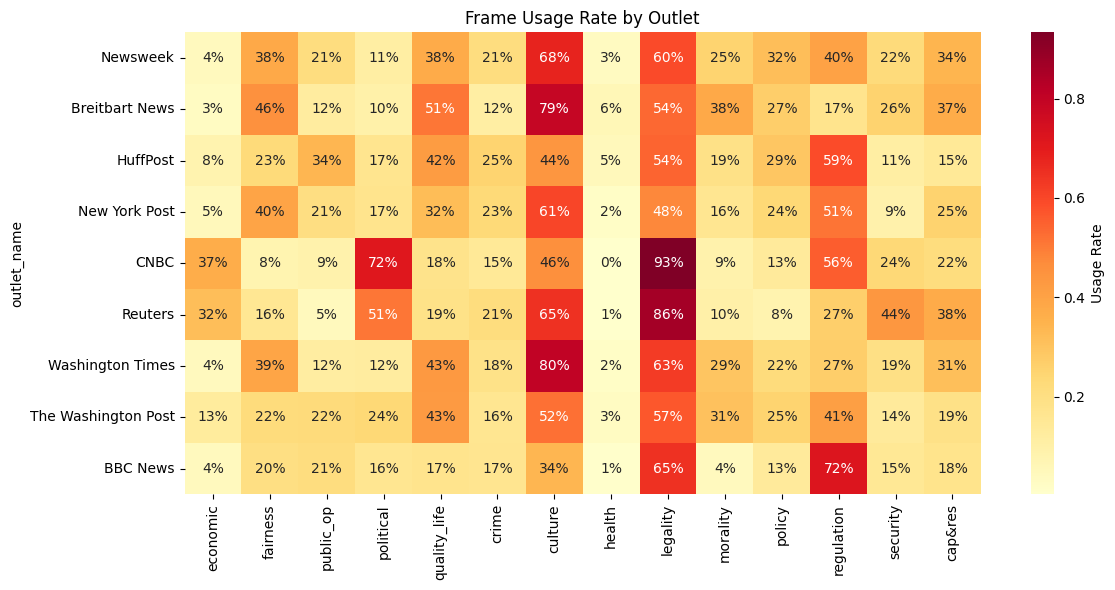


Frame usage ranges across outlets:


,frame,min,max,range
3,political,10%,72%,62%
11,regulation,17%,72%,55%
6,culture,34%,80%,46%
8,legality,48%,93%,46%
1,fairness,8%,46%,38%
12,security,9%,44%,34%


In [13]:
# Frame usage by outlet
outlet_frames = df.groupby('outlet_name')[frame_cols].mean()
outlet_frames.columns = frames
outlet_frames['n_articles'] = df.groupby('outlet_name').size()
outlet_frames = outlet_frames.sort_values('n_articles', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(outlet_frames[frames], annot=True, fmt='.0%', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Usage Rate'})
plt.title('Frame Usage Rate by Outlet')
plt.tight_layout()
plt.show()

# Show ranges
print('\nFrame usage ranges across outlets:')
ranges = [(f, outlet_frames[f].min(), outlet_frames[f].max(), outlet_frames[f].max() - outlet_frames[f].min()) for f in frames]
ranges_df = pd.DataFrame(ranges, columns=['frame', 'min', 'max', 'range']).sort_values('range', ascending=False).head(6)
ranges_df.style.format({'min': '{:.0%}', 'max': '{:.0%}', 'range': '{:.0%}'})

## 2. Left and Right Outlets Frame Stories Differently

**Claim:** Political valence is associated with systematic differences in frame usage (10-16% on key frames).

**Evidence:** Chi-square tests show all frame-valence associations are statistically significant (p < 0.05).

*See: `Outlet_Framing_Analysis.ipynb` for topic-specific breakdowns*

In [14]:
# Frame usage by valence
valence_frames = df.groupby('valence')[frame_cols].mean()
valence_frames.columns = frames
valence_frames = valence_frames.loc[['Left', 'Center', 'Right']]

# Left - Right difference
diff = valence_frames.loc['Left'] - valence_frames.loc['Right']

# Chi-square tests
chi2_results = []
for frame in frames:
    contingency = pd.crosstab(df['valence'], df[f'frame_{frame}'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({'frame': frame, 'left_minus_right': diff[frame], 'chi2': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('left_minus_right', key=abs, ascending=False)

# Custom colormap: brown (Right) -> white -> green (Left)
from matplotlib.colors import LinearSegmentedColormap
colors = ['#8B4513', '#FFFFFF', '#228B22']  # brown, white, green
cmap_custom = LinearSegmentedColormap.from_list('BrownGreen', colors)

print('Left vs Right Frame Usage Differences (with statistical significance):')
print('(positive/green = Left uses more, negative/brown = Right uses more)\n')
chi2_df[['frame', 'left_minus_right', 'p_value']].style.format({'left_minus_right': '{:+.1%}', 'p_value': '{:.2e}'}).background_gradient(subset=['left_minus_right'], cmap=cmap_custom, vmin=-0.2, vmax=0.2)

Left vs Right Frame Usage Differences (with statistical significance):
(positive/green = Left uses more, negative/brown = Right uses more)



,frame,left_minus_right,p_value
11,regulation,+16.4%,0.00e+00
6,culture,-14.1%,0.00e+00
2,public_op,+10.2%,0.00e+00
1,fairness,-10.2%,0.00e+00
9,morality,-5.8%,0.00e+00
5,crime,+5.7%,1.31e-77
10,policy,+5.5%,0.00e+00
13,cap&res,-4.9%,1.28e-48
4,quality_life,-4.4%,0.00e+00
8,legality,+4.0%,0.00e+00


## 3. Frame Co-occurrence Patterns Differ by Outlet

**Claim:** Outlets combine frames differently - the same frame pairs co-occur at vastly different rates.

**Evidence:** 24-45% ranges in co-occurrence rates for top frame pairs.

*See: `Frame_Cooccurrence_Analysis.ipynb` for full co-occurrence matrices*

In [4]:
from itertools import combinations

# Top global frame pairs
cooccur = frame_matrix.T @ frame_matrix
pairs = []
for i, j in combinations(range(len(frames)), 2):
    pairs.append({'frame_1': frames[i], 'frame_2': frames[j], 'count': cooccur[i, j]})
top_pairs = pd.DataFrame(pairs).sort_values('count', ascending=False).head(5)

# Co-occurrence by outlet
comparison = []
for outlet in df['outlet_name'].unique():
    subset = df[df['outlet_name'] == outlet]
    mat = np.array(subset['vector'].tolist())
    outlet_cooccur = mat.T @ mat
    row = {'outlet': outlet}
    for _, pair in top_pairs.iterrows():
        i, j = frames.index(pair['frame_1']), frames.index(pair['frame_2'])
        pair_name = f"{pair['frame_1']}-{pair['frame_2']}"
        row[pair_name] = outlet_cooccur[i, j] / len(subset)
    comparison.append(row)

comparison_df = pd.DataFrame(comparison).set_index('outlet')

print('Co-occurrence rate ranges across outlets:\n')
for col in comparison_df.columns:
    vals = comparison_df[col]
    print(f'{col}: {vals.min():.0%} - {vals.max():.0%} (range: {vals.max()-vals.min():.0%})')

Co-occurrence rate ranges across outlets:

culture-legality: 26% - 55% (range: 29%)
quality_life-culture: 9% - 43% (range: 34%)
fairness-culture: 7% - 40% (range: 33%)
legality-regulation: 9% - 53% (range: 45%)
culture-cap&res: 7% - 31% (range: 24%)


## 4. Major Events Produce Measurable Frame Shifts

**Claim:** Frame usage shifts notably around major news events (5-19% changes).

**Evidence:** Event-quarter framing differs substantially from the 2 quarters prior.

**Caveat:** This is correlation, not causation. Events in 2020 overlap and cannot be disentangled.

*See: `Event_Framing_Analysis.ipynb` for valence-specific and topic-specific event analysis*

In [ ]:
events = [
    {'name': '2016 Election', 'quarter': '2016Q4'},
    {'name': 'Charlottesville', 'quarter': '2017Q3'},
    {'name': 'Parkland Shooting', 'quarter': '2018Q1'},
    {'name': 'COVID-19 Start', 'quarter': '2020Q1'},
    {'name': 'George Floyd', 'quarter': '2020Q2'},
    {'name': '2020 Election', 'quarter': '2020Q4'},
    {'name': 'Jan 6 Riot', 'quarter': '2021Q1'},
]

def frame_change_around_event(event_q, n_before=2):
    quarters_list = sorted(df['quarter'].unique())
    event_idx = quarters_list.index(pd.Period(event_q))
    if event_idx < n_before:
        return None
    before_qs = quarters_list[event_idx - n_before:event_idx]
    before_mean = df[df['quarter'].isin(before_qs)][frame_cols].mean()
    event_mean = df[df['quarter'] == quarters_list[event_idx]][frame_cols].mean()
    change = event_mean - before_mean
    change.index = frames
    return change

event_changes = {e['name']: frame_change_around_event(e['quarter']) for e in events}
event_changes = {k: v for k, v in event_changes.items() if v is not None}
change_df = pd.DataFrame(event_changes).T

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(change_df, annot=True, fmt='+.0%', cmap='PiYG', center=0, ax=ax, cbar_kws={'label': 'Change from 2Q prior'})
plt.title('Frame Usage Change at Event vs 2 Quarters Before')
plt.tight_layout()
plt.show()

print('\nLargest shifts per event:')
for event_name, changes in event_changes.items():
    top = changes.abs().idxmax()
    print(f'  {event_name}: {top} {changes[top]:+.1%}')

## 5. Gradual Frame Drift Over 2015-2021 Was Minimal

**Claim:** Frame usage was relatively stable over the 7-year period. Changes were ~1-2% per year.

**Evidence:** Linear regression on quarterly data shows small slopes with weak fits (low r²).

*See: `Framing_Drift_Analysis.ipynb` for topic-specific and outlet-specific trends*

In [ ]:
quarterly_global = df.groupby('quarter')[frame_cols].mean()
x = np.arange(len(quarterly_global))

trends = []
for frame_col in frame_cols:
    y = quarterly_global[frame_col].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    trends.append({'frame': frame_col.replace('frame_', ''), 'slope_per_year': slope * 4, 'r_squared': r_value ** 2, 'p_value': p_value})

trend_df = pd.DataFrame(trends).sort_values('slope_per_year', key=abs, ascending=False)

print('Global Frame Trends (2015-2021):\n')
trend_df.style.format({'slope_per_year': '{:+.2%}', 'r_squared': '{:.3f}', 'p_value': '{:.4f}'}).background_gradient(subset=['slope_per_year'], cmap='PiYG', vmin=-0.02, vmax=0.02)

---
# UNSUPPORTED CLAIMS
---

## UNSUPPORTED: "Media is becoming more polarized over time"

**Why not:** The Left-Right framing gap actually shrank slightly (-0.47%/year, p=0.008), though this effect is too small to be meaningful. There is no evidence of increasing polarization.

In [7]:
# Left-Right gap over time
quarterly_gap = []
for quarter in sorted(df['quarter'].unique()):
    q_df = df[df['quarter'] == quarter]
    left_mean = q_df[q_df['valence'] == 'Left'][frame_cols].mean()
    right_mean = q_df[q_df['valence'] == 'Right'][frame_cols].mean()
    gap = (left_mean - right_mean).abs().mean()
    quarterly_gap.append({'quarter': quarter, 'avg_gap': gap})

gap_df = pd.DataFrame(quarterly_gap).sort_values('quarter')
x = np.arange(len(gap_df))
y = gap_df['avg_gap'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f'Left-Right gap trend: {slope*4:+.2%} per year')
print(f'p-value: {p_value:.4f}, r²: {r_value**2:.3f}')
print(f'\nFirst quarter gap: {gap_df.iloc[0]["avg_gap"]:.1%}')
print(f'Last quarter gap: {gap_df.iloc[-1]["avg_gap"]:.1%}')
print(f'\n→ Gap is too small and r² too low to claim meaningful convergence or divergence.')

Left-Right gap trend: -0.47% per year
p-value: 0.0078, r²: 0.242

First quarter gap: 6.7%
Last quarter gap: 5.4%

→ Gap is too small and r² too low to claim meaningful convergence or divergence.


## UNSUPPORTED: "Left and Right responded differently to George Floyd"

**Why not:** George Floyd actually showed **low** Left-Right divergence (1.6%). Both sides shifted framing similarly. Higher divergence occurred at 2020 Election (4.5%) and Parkland (3.6%).

In [8]:
def frame_change_by_valence(event_q, n_before=2):
    quarters_list = sorted(df['quarter'].unique())
    event_idx = quarters_list.index(pd.Period(event_q))
    if event_idx < n_before:
        return None
    before_qs = quarters_list[event_idx - n_before:event_idx]
    results = {}
    for valence in ['Left', 'Right']:
        v_df = df[df['valence'] == valence]
        before_mean = v_df[v_df['quarter'].isin(before_qs)][frame_cols].mean()
        event_mean = v_df[v_df['quarter'] == quarters_list[event_idx]][frame_cols].mean()
        results[valence] = event_mean - before_mean
    return pd.DataFrame(results)

divergence_data = []
for event in events:
    vc = frame_change_by_valence(event['quarter'])
    if vc is not None:
        divergence_data.append({'event': event['name'], 'avg_divergence': (vc['Left'] - vc['Right']).abs().mean()})

div_df = pd.DataFrame(divergence_data).sort_values('avg_divergence', ascending=False)
print('Average Left-Right divergence by event:\n')
div_df.style.format({'avg_divergence': '{:.1%}'}).bar(subset=['avg_divergence'], color='#5fba7d')

Average Left-Right divergence by event:



,event,avg_divergence
5,2020 Election,4.5%
2,Parkland Shooting,3.6%
0,2016 Election,3.1%
6,Jan 6 Riot,2.3%
3,COVID-19 Start,1.7%
4,George Floyd,1.6%
1,Charlottesville,1.6%


## UNSUPPORTED: "Event X caused framing to change"

**Why not:** We show correlation (framing shifted around events), not causation. The comparison method (event quarter vs 2 quarters before) is exploratory. Events in 2020 overlap, making attribution impossible.

## UNSUPPORTED: "Topic X saw a significant shift in framing"

**Why not:** Per-topic trends have smaller sample sizes and noisier data. While some topic-frame combinations show larger slopes than the global average, low r-squared values indicate inconsistent trends. These could be artifacts of events rather than systematic change.

*See: `Framing_Drift_Analysis.ipynb` for per-topic trend summary and statistics*

---
# Summary

| Finding | Confidence | Key Evidence |
|---------|------------|-------------|
| Outlets have distinct framing fingerprints | HIGH | Wide usage ranges across outlets, chi-square p < 0.05 for all frames |
| Left/Right valence differs systematically | HIGH | 10-16% differences, all chi-square p < 0.05 |
| Frame co-occurrence varies by outlet | HIGH | 24-45% ranges in co-occurrence rates |
| Events shift framing temporarily | MEDIUM | 5-19% shifts, but correlation only |
| Gradual drift is minimal | HIGH | ~1%/year slopes, many not significant |
| Polarization is increasing | NOT SUPPORTED | No evidence; slight convergence if anything |